# 20260630 pairwise interaction — relative abundance & competitive hierarchy

Same method as the [20260721 relative_abundance analysis](../../../20260721/analysis/relative_abundance/relative_abundance_20260721.ipynb),
run here via the shared, experiment-parameterized pipeline in `../../../shared_pipelines/`.

**Reference**: `analysis/consensus2/strain_consensus_20260630.fasta` (84 strains — the more
recent/refined of two independent per-strain consensus builds for this experiment).
**Guide**: `setup/strain_layout_20260630.csv`. **Cohort**: the same >5-read pair wells
already identified in `analysis/mapping_validation` (2,778 wells, of which 1,968 have a
resolvable reference for both strains).

Same five questions as 20260721:

1. **Interaction score per well** — reads matching neither expected strain are quantified,
   not discarded; (near-)identical strain pairs fall out to 50/50 with maximal uncertainty
   automatically, from the same classifier used for every other pair.
2. **Replicate stability** — for strain pairs plated more than once, does the score reproduce?
3. **Per-strain competitiveness score** — averaged across every distinct opponent tested.
4. **Hierarchy vs. tangled network** — Bradley-Terry model + Directional Consistency Index +
   intransitive-triad fraction.
5. **Is that hierarchy statistically significant** — permutation test + goodness-of-fit test.


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR.parent))  # analysis/ (config.py lives here, shared by both pipelines)

import pandas as pd
from IPython.display import Image, display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

from config import CFG  # also puts shared_pipelines/ on sys.path as a side effect

OUT_DIR = CFG.relative_abundance_out_dir
FIG_DIR = CFG.relative_abundance_fig_dir

def show(png_name, width=880):
    display(Image(filename=str(FIG_DIR / png_name), width=width))

print(f"reference -> {CFG.ra_reference_fasta}")
print(f"cohort    -> {CFG.mapping_validation_out_dir / '01_samples_gt5reads.csv'}")
print(f"outputs   -> {OUT_DIR}")


reference -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/consensus2/strain_consensus_20260630.fasta
cohort    -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/01_samples_gt5reads.csv
outputs   -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs


## Step 1 — reference-pair distances

For every unique strain pair actually tested, how far apart are the two strains' own
reference sequences? **This strain library has a notably larger near-identical cluster than
20260721's**: 12 pairs with completely identical (0bp) references (vs. 1 for 20260721), and
103 pairs within 10bp (vs. 31) — expect a higher uncertainty rate throughout this analysis as
a direct consequence.


In [2]:
from relative_abundance import reference_distances

ref_dist = reference_distances(CFG)
display(ref_dist.sort_values("bp_dist").head(10))


2365 unique tested strain pairs (688 missing a reference for one strain)
reference-pair bp distance among resolvable pairs: min=0, median=202, max=338
pairs with identical (0 bp) references: 12
pairs with <10 bp difference: 103
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r01_reference_pair_distances.csv


,strain_a,strain_b,bp_dist,norm_dist,len_a,len_b,missing_reference
504,C20,E22,0.0,0.0,1423.0,1423.0,False
1768,G17,J13,0.0,0.0,1419.0,1419.0,False
457,C14,E4,0.0,0.0,1421.0,1421.0,False
899,E16,E21,0.0,0.0,1431.0,1431.0,False
709,E10,G3,0.0,0.0,1422.0,1422.0,False
710,E10,G5,0.0,0.0,1422.0,1422.0,False
1747,G15,O9,0.0,0.0,1422.0,1422.0,False
2092,H15,H17,0.0,0.0,1422.0,1422.0,False
1933,G3,G5,0.0,0.0,1422.0,1422.0,False
1605,G1,H15,0.0,0.0,1422.0,1422.0,False


## Step 2 — per-well interaction scoring

In [3]:
from relative_abundance import compute_interaction_scores

wells, reads = compute_interaction_scores(CFG)


data-driven off-target threshold (learned from 1968 wells' read distances): 0.128


2778 pair wells (810 skipped, missing a reference for one strain)
82070 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r02_read_assignments.csv.gz
read_class breakdown:
read_class
ambiguous     28543
strain2       25613
strain1       23930
off_target     3984

median off_target_frac: 0.000
median uncertainty_score: 0.039
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r02_well_interaction_scores.csv


In [4]:
display(Markdown("**A concrete illustration** -- an indistinguishable pair vs. a well-separated one:"))
example_cols = ["sample_id", "strain1", "strain2", "n_reads", "ref_pair_bp_dist",
                "uncertainty_score", "relative_abundance_strain1", "log2_ratio_strain1_over_strain2"]
indistinguishable = wells[(wells.ref_pair_bp_dist == 0)].head(3)
separated = wells.sort_values("ref_pair_bp_dist", ascending=False).head(1)
display(pd.concat([indistinguishable, separated])[example_cols])


**A concrete illustration** -- an indistinguishable pair vs. a well-separated one:

,sample_id,strain1,strain2,n_reads,ref_pair_bp_dist,uncertainty_score,relative_abundance_strain1,log2_ratio_strain1_over_strain2
318,Plate03_C19,E22,C20,41,0.0,1.0,0.5,0.000000
606,Plate05_C14,G3,E10,34,0.0,1.0,0.5,0.000000
1037,Plate07_J10,G5,G3,40,0.0,1.0,0.5,0.000000
1303,Plate09_H4,A6,E6,40,338.0,0.0,0.4,-0.570316


In [5]:
from relative_abundance import make_all_figures

make_all_figures(CFG)


saved 8 figures -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/figures


**Read classification & per-well quality**, and the overall interaction-outcome distribution:

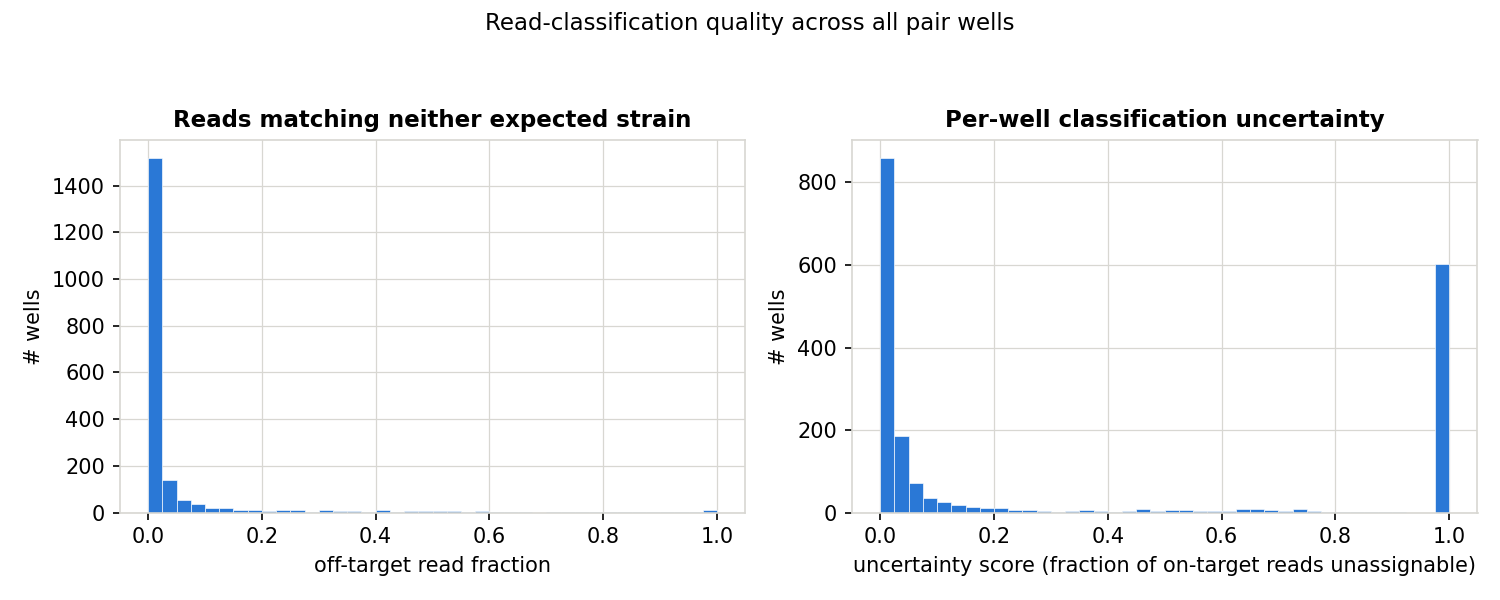

In [6]:
show("00_read_classification_quality.png")

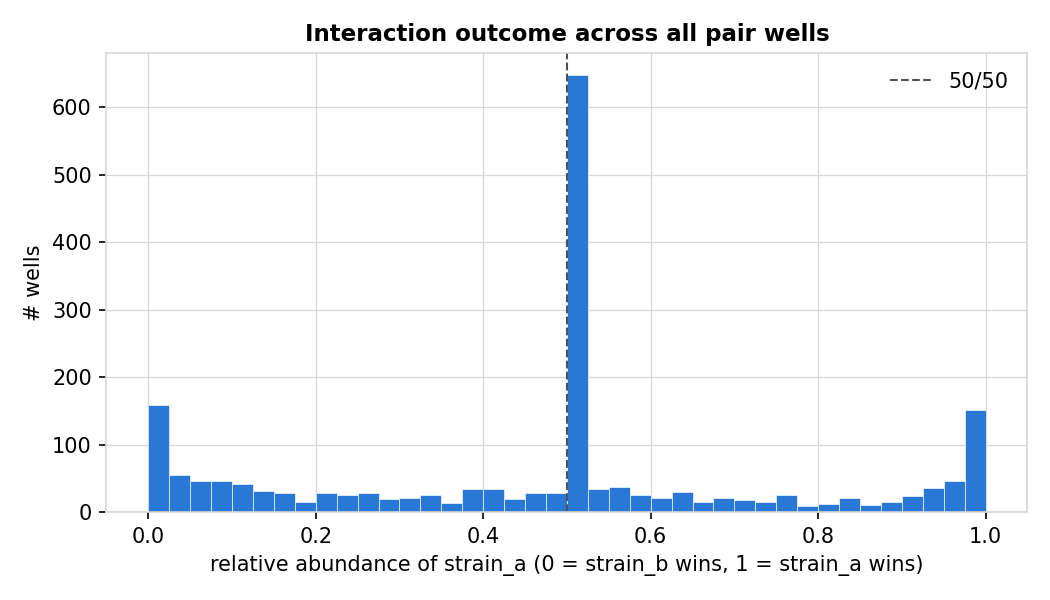

In [7]:
show("01_abundance_distribution.png")

## Step 3 — replicate stability

In [8]:
from relative_abundance import replicate_stability

pair_stats = replicate_stability(CFG)


1677 unique pairs total; 291 have >=2 replicate wells
  of which 169 are NOT high-uncertainty (reliable measurement)
  median std(relative_abundance_a) across replicated pairs: 0.011
  median std, excluding high-uncertainty pairs: 0.030
  flagged unstable (std > 0.15): 11
  flagged unstable AND not high-uncertainty (genuine biological instability): 11
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r03_pair_replicate_stats.csv


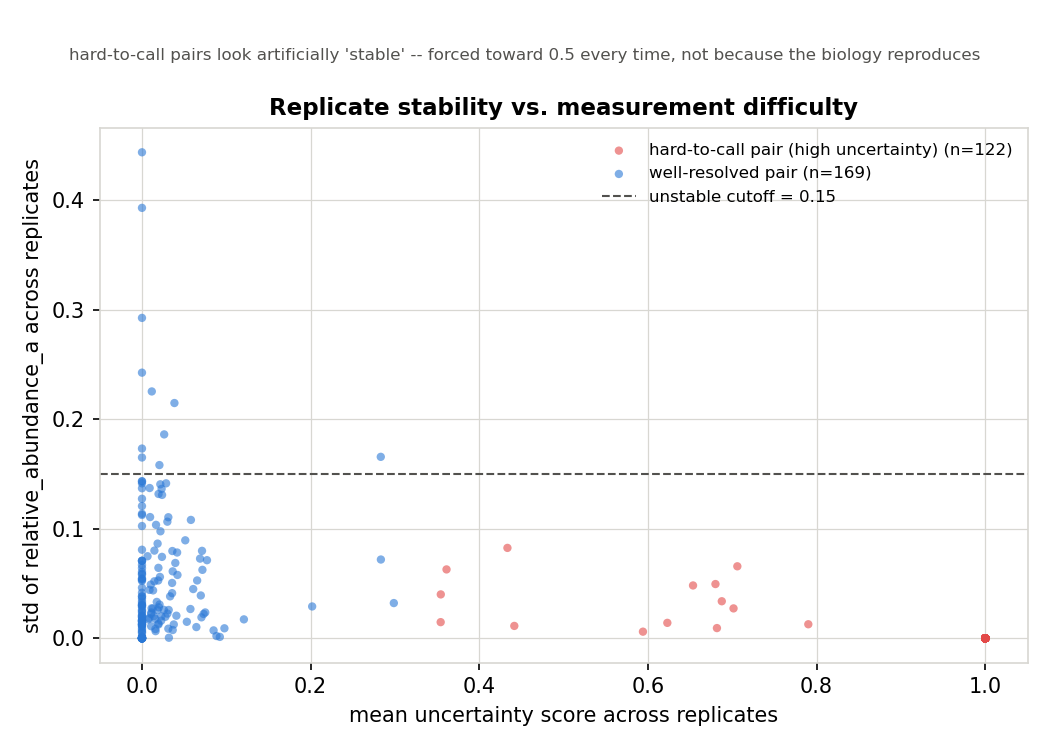

In [9]:
show("02_replicate_stability.png")

In [10]:
unstable = pair_stats[pair_stats.unstable_replicate & ~pair_stats.high_uncertainty_pair]
display(Markdown(f"**{len(unstable)} pairs show genuine (not measurement-driven) replicate instability**:"))
display(unstable.sort_values("std_relative_abundance_a", ascending=False)
        [["strain_a","strain_b","n_replicates","mean_relative_abundance_a","std_relative_abundance_a","mean_uncertainty_score"]]
        .head(10))


**11 pairs show genuine (not measurement-driven) replicate instability**:

,strain_a,strain_b,n_replicates,mean_relative_abundance_a,std_relative_abundance_a,mean_uncertainty_score
1241,G2,M19,2,0.413636,0.443549,0.000000
1208,G17,G9,2,0.722222,0.392837,0.000000
1429,G8,O7,2,0.635338,0.292413,0.000000
107,A12,G7,2,0.828571,0.242437,0.000000
164,A21,A6,2,0.759302,0.225288,0.011628
1656,O17,O9,2,0.309717,0.214709,0.038462
1405,G7,M19,2,0.368421,0.186081,0.026316
52,A11,F17,2,0.254025,0.173165,0.000000
830,E24,J1,2,0.336393,0.165597,0.283150
245,A6,M11,2,0.883333,0.164992,0.000000


## Step 4 — per-strain competitiveness score

In [11]:
from relative_abundance import competitiveness_scores

comp = competitiveness_scores(CFG)


76/100 strains scored
  NOT scored (no resolvable reference / no tested pairs survived filtering): ['A10', 'A15', 'A2', 'E14', 'E15', 'E5', 'E8', 'F21', 'G10', 'G11', 'G12', 'G13', 'G14', 'G18', 'G19', 'G23', 'H5', 'H7', 'I3', 'J11', 'J3', 'M9', 'P21', 'P23']

top 5 most competitive:
strain  competitiveness_score  win_fraction  n_opponents
   J13               2.941990      0.860465           43
    J5               2.306151      0.790698           43
   O17               2.230489      0.666667           42
   G17               2.182234      0.843137           51
   F15               1.867834      0.500000           42

bottom 5 least competitive:
strain  competitiveness_score  win_fraction  n_opponents
   P19              -2.334654      0.000000           38
   O11              -2.363729      0.000000           46
   E20              -2.478254      0.028571           35
   O21              -2.496761      0.230769           39
   M13              -3.025786      0.000000           38

s

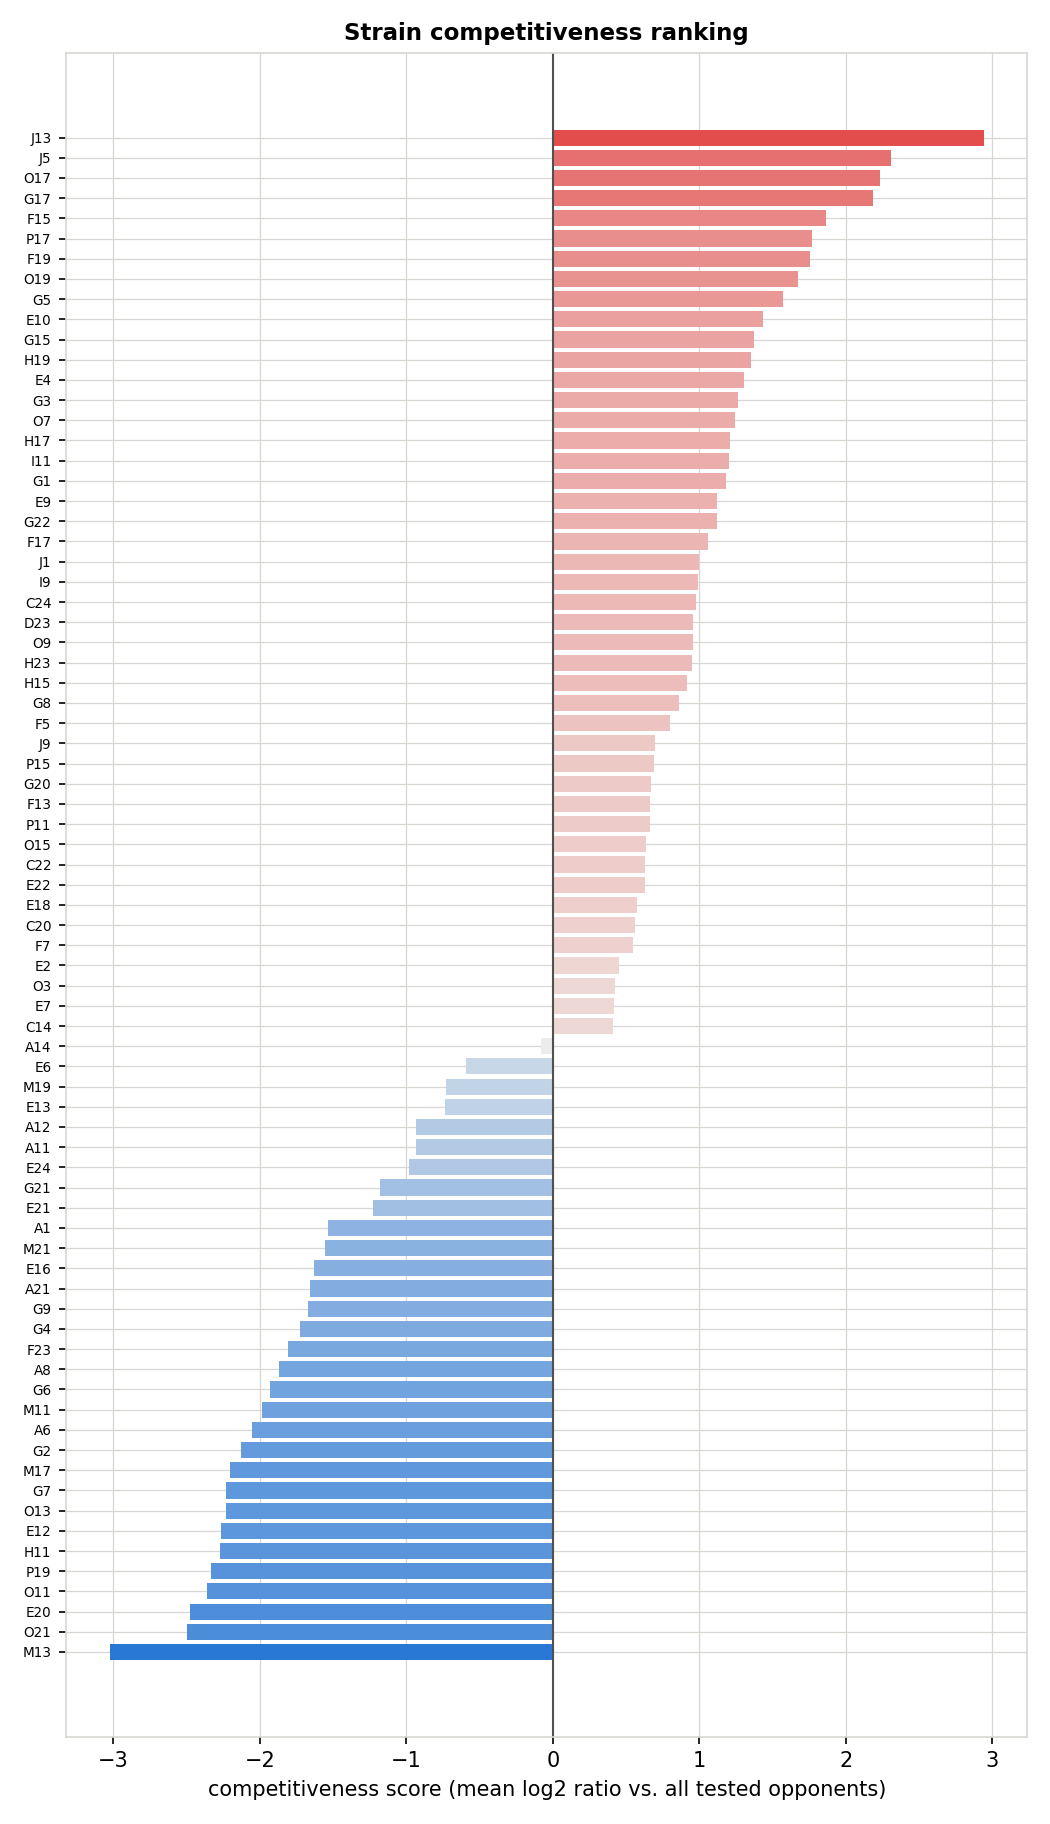

In [12]:
show("03_competitiveness_ranking.png", width=700)

## Step 5 — hierarchy vs. tangled network

In [13]:
from relative_abundance import hierarchy_analysis

bt, mat, win, hsummary = hierarchy_analysis(CFG)


76 strains with resolvable pairwise data
connected components: [76]



Bradley-Terry pseudo-R^2 (deviance explained by a single 1-D strength ranking): 0.831
median BT-residual sd across strains: 2.32 log2 units (the genuine, opponent-strength-corrected unpredictability of a strain's outcomes)


Directional Consistency Index (rank = total wins): 0.670  (970 consistent, 192 upsets)


Intransitive (cyclic) triads: 142/5746 evaluated (0.025)

saved -> r05_pairwise_relative_abundance_matrix.csv, r05_bt_strengths.csv, r05_hierarchy_summary.csv


In [14]:
display(hsummary)

,metric,value
0,n_strains_in_main_component,76.000000
1,n_components,1.000000
2,bt_pseudo_r2,0.831085
3,dci,0.669535
4,dci_n_consistent,970.000000
5,dci_n_inconsistent_upsets,192.000000
6,frac_intransitive_triads,0.024713
7,n_intransitive_triads,142.000000
8,n_triads_evaluated,5746.000000


**Pairwise outcome heatmap**, ordered by Bradley-Terry strength:

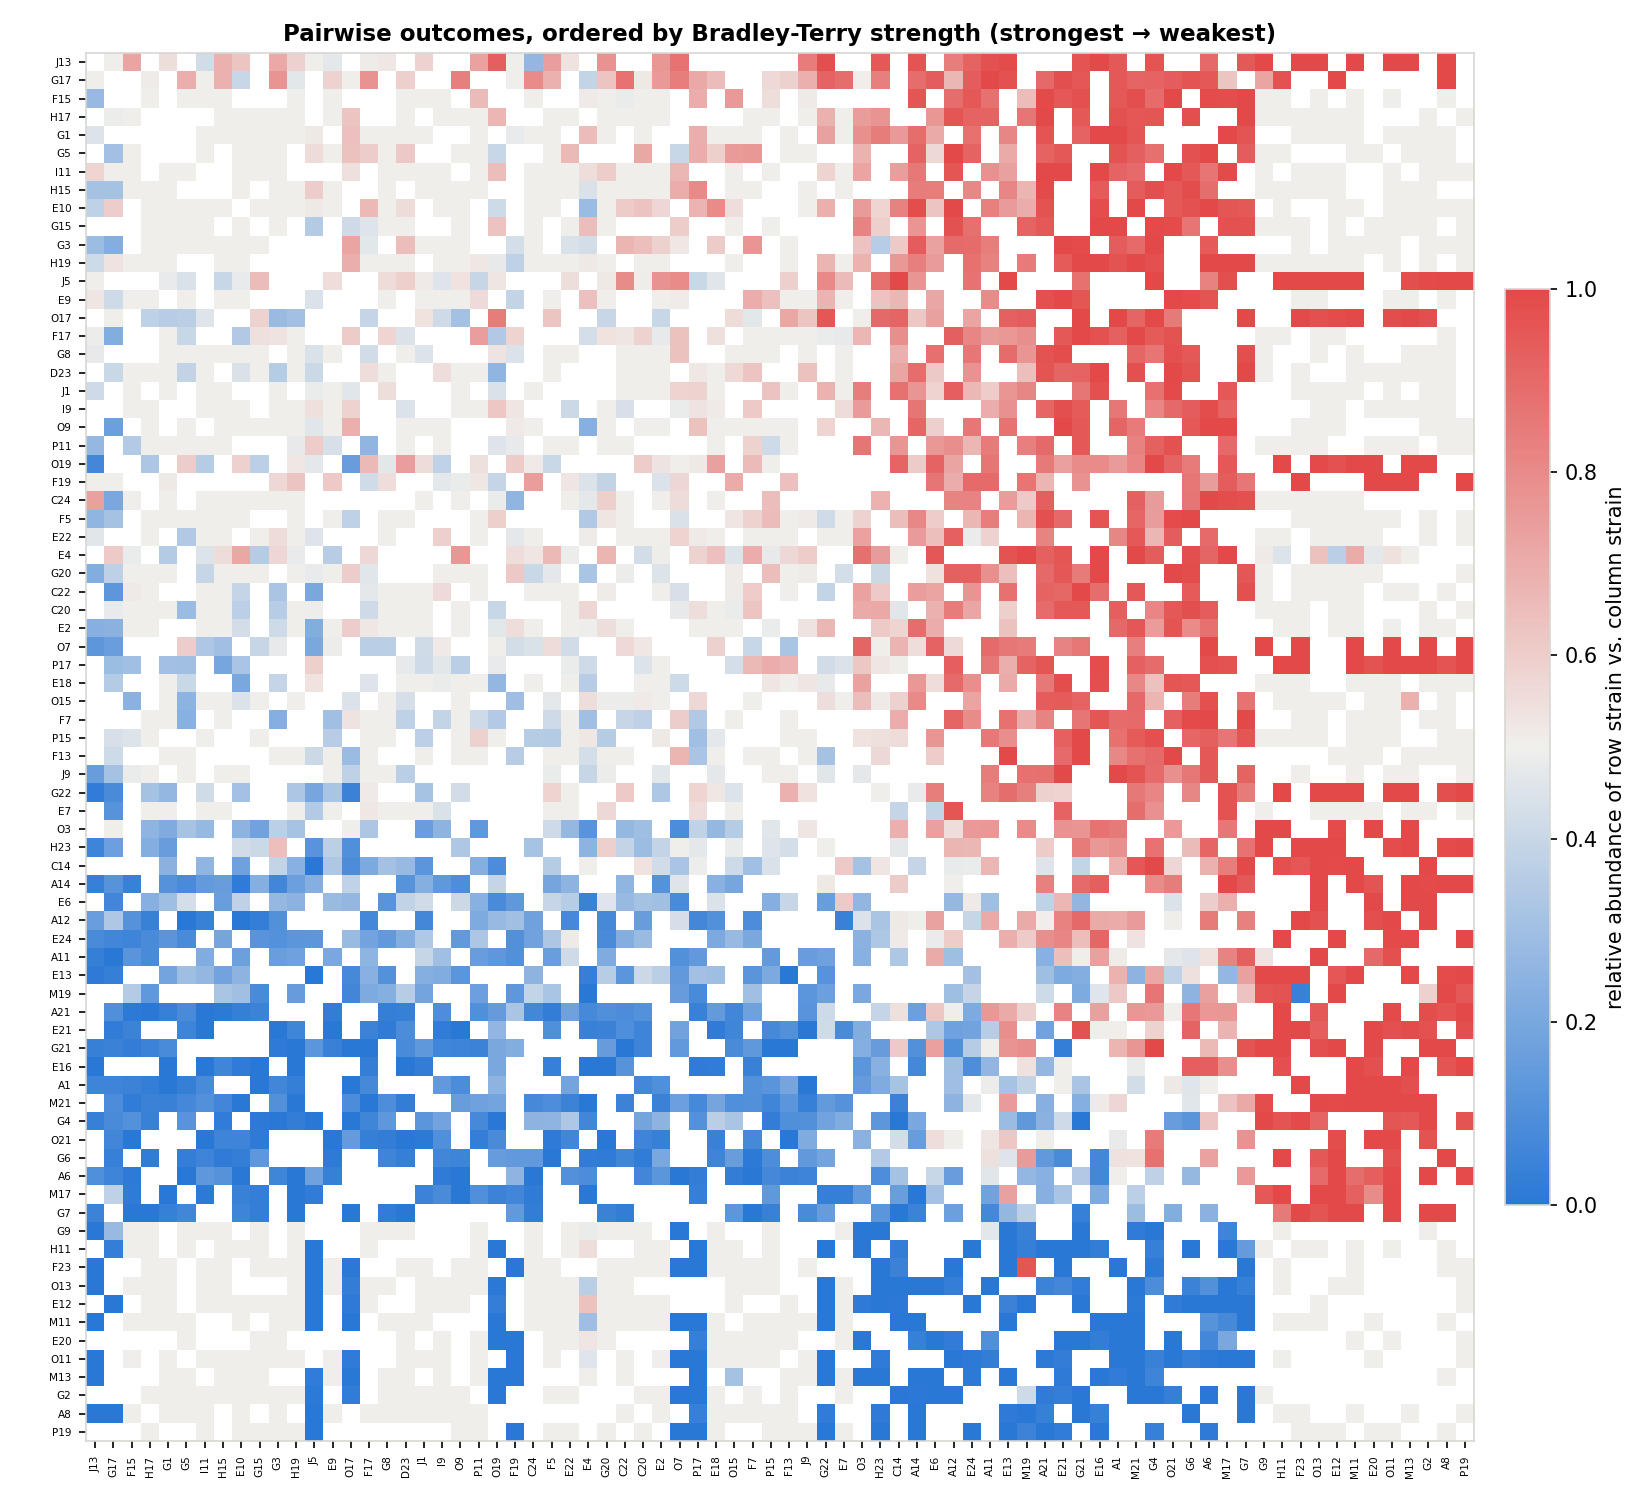

In [15]:
show("05_hierarchy_heatmap.png", width=780)

**Do the two independent competitiveness estimates agree?**

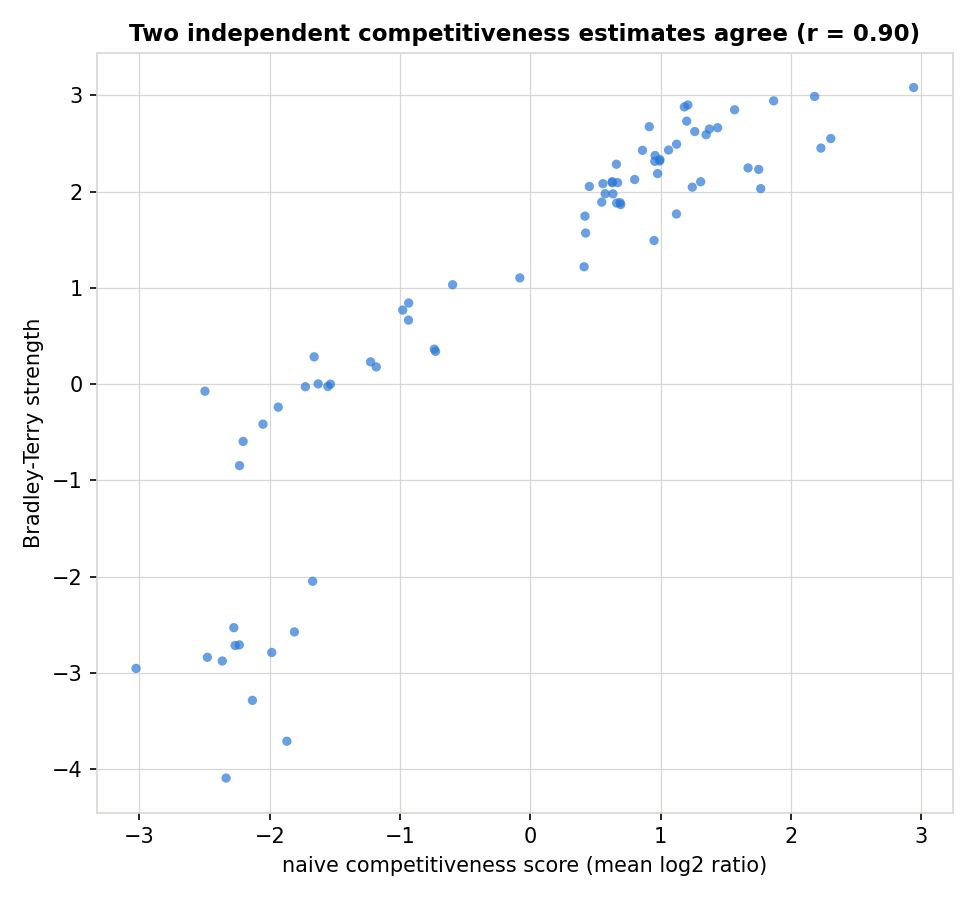

In [16]:
show("06_bt_vs_naive_competitiveness.png", width=520)

**Consistent dominance/loss vs. context-dependent outcomes**:

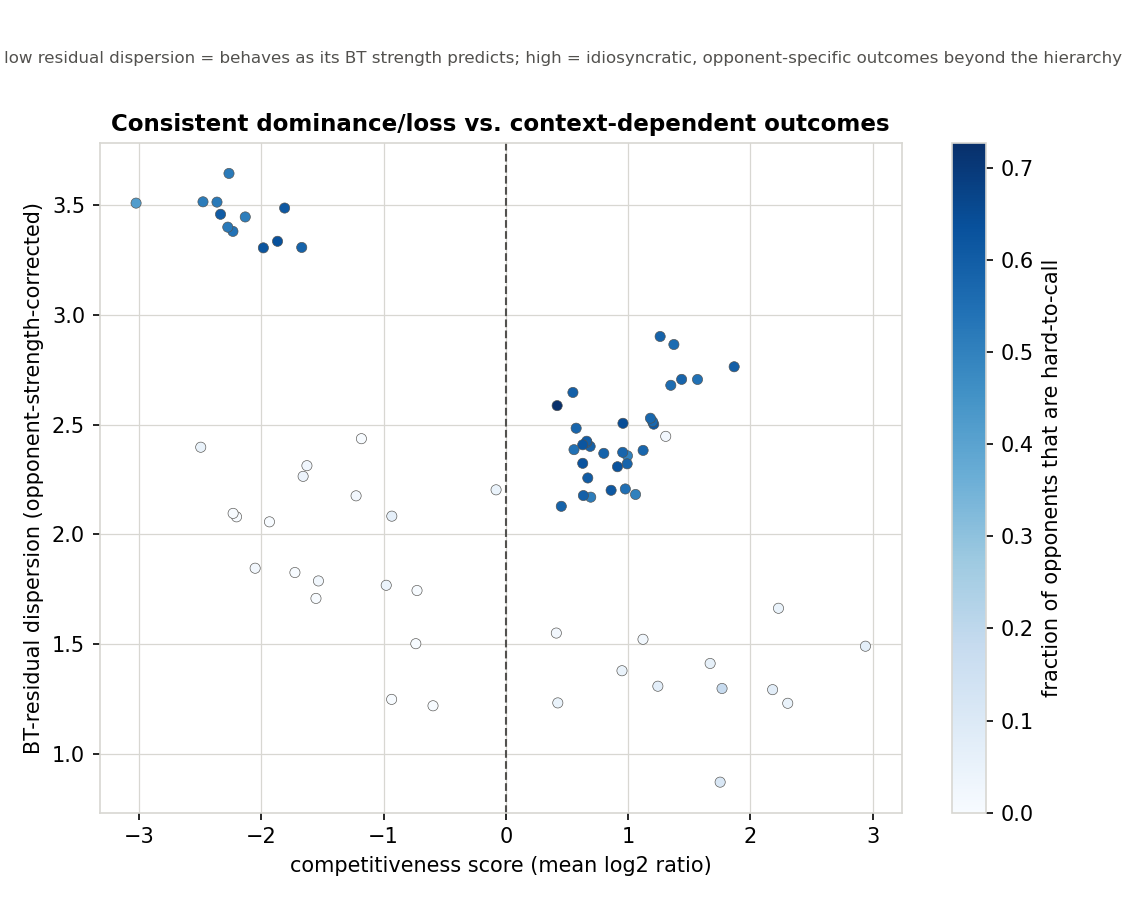

In [17]:
show("04_mean_vs_dispersion.png", width=680)

**Hierarchy consistency, summarized**:

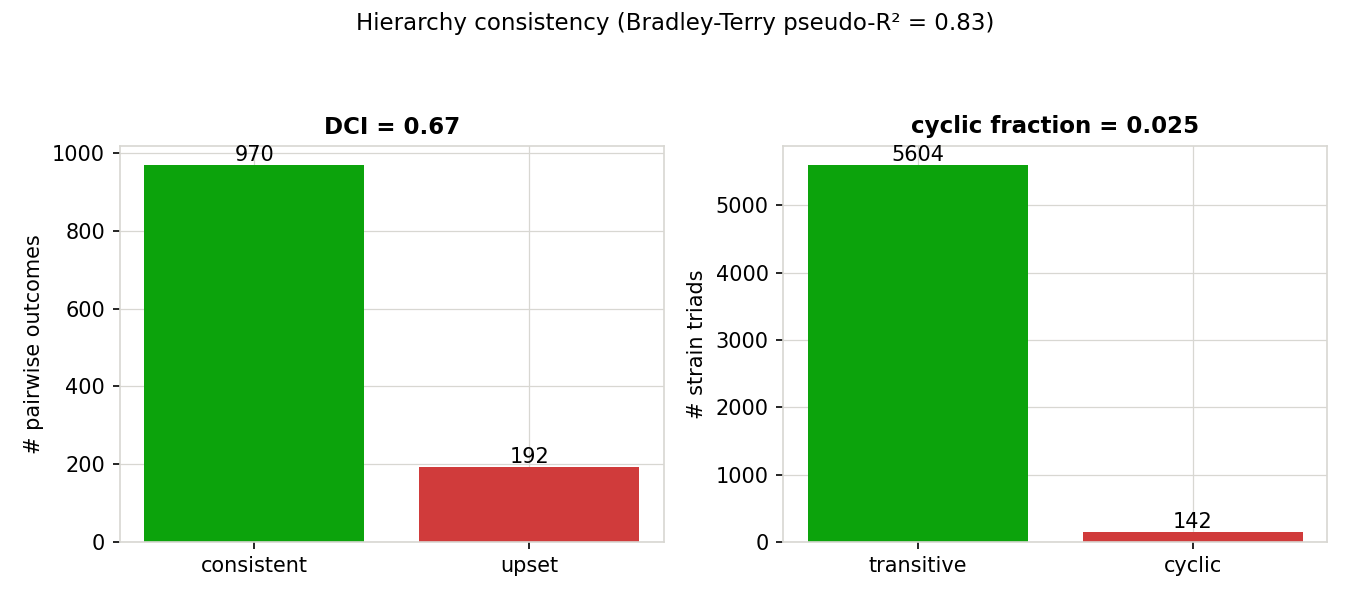

In [18]:
show("07_hierarchy_consistency.png", width=780)

## Step 6 — is the hierarchy statistically significant?

Step 5's three statistics (Bradley-Terry pseudo-R^2, DCI, cyclic-triad fraction) are
descriptive: they say "this looks hierarchical" without a p-value attached. Two formal tests
close that gap:

1. **Permutation test** — the standard randomization-test approach from the behavioral-ecology
   dominance-hierarchy literature (e.g. de Vries 1998). For every tested pair with a clear
   winner, redraw the winner with a fair coin flip, recompute DCI and the cyclic-triad
   fraction, and repeat thousands of times to build a null distribution for "these strains
   have no real consistent ranking at all." The observed values are compared against that
   null. (The win/loss arithmetic here is a numpy-vectorized reimplementation, needed for
   speed at thousands of iterations — it's validated to reproduce step 5's exact numbers on
   the real data before being trusted inside the permutation loop.)
2. **Bradley-Terry goodness-of-fit** — two likelihood-ratio chi-squared tests that are
   essentially free given the already-fit model: (a) do strains differ at all (vs. the null
   of one shared strength for everyone), and (b) is a *single* 1-D strength scale a
   *sufficient* description, or is there significant leftover structure a hierarchy can't
   capture? Test (b) is a standard deviance goodness-of-fit test for a grouped-binomial GLM —
   the model's residual deviance is compared to a chi-squared(df_resid) reference
   distribution. Because the read counts here are large, the p-value for test (b) will reject
   any imperfect model, however good — so we also report the **dispersion ratio**
   (deviance / df_resid), a sample-size-independent effect size: how many times more residual
   variation there is than a perfectly-fitting hierarchy would show from sampling noise alone.


In [19]:
from hierarchy_significance import permutation_test, bt_goodness_of_fit, make_significance_figures

perm_summary, null_dci, null_cyclic = permutation_test(CFG, n_permutations=5000, seed=0)

validated fast DCI/cyclic-fraction implementations against the reference (exact match)
observed DCI = 0.670  |  null (no-hierarchy) DCI = 0.061 +/- 0.027  |  p = 0.0002
observed cyclic fraction = 0.025  |  null cyclic fraction = 0.250 +/- 0.006  |  p = 0.0002
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r07_permutation_test.csv, /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r07_permutation_null_distributions.csv


In [20]:
gof_summary = bt_goodness_of_fit(CFG)

LR test (do strains differ at all?): stat=27823.6, df=75, p=0
deviance GoF test (is a single 1-D hierarchy a SUFFICIENT description?): deviance=5655.0, df_resid=1098, p=0, dispersion ratio=5.15x
  (with this many reads, the p-value alone will reject any imperfect model; the dispersion ratio is the sample-size-independent effect size -- 5.2x more residual variation than a perfect-fitting hierarchy would show from sampling noise alone)
  -> significant: there is real structure beyond a single hierarchy ranking (consistent with the nonzero upset rate / cyclic-triad fraction already observed)
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r08_bt_goodness_of_fit.csv


**Test 3 — is the intransitivity itself more than a perfect hierarchy's own noise would produce?**
The permutation test above asks "hierarchy vs. pure chance." This is a sharper question:
*assuming the fitted Bradley-Terry model is exactly true*, would its own sampling noise (at
each pair's actual read depth) produce this much apparent intransitivity on its own? Simulate
new outcomes from the fitted strengths at the real per-pair read counts, thousands of times,
and compare the observed cyclic-triad fraction to that noise band.

In [21]:
from hierarchy_significance import parametric_bootstrap_intransitivity

boot_intrans_summary, boot_null_cyclic, boot_null_dci = parametric_bootstrap_intransitivity(CFG, n_simulations=2000, seed=0)

observed cyclic fraction = 0.025  |  BT-model + sampling-noise-alone cyclic fraction = 0.009 +/- 0.002  |  p = 0.0004998
  -> significant: there is MORE intransitivity than a perfect hierarchy's own sampling noise would produce -- real excess non-hierarchical structure, not just noise
(for comparison: observed DCI = 0.670 vs. BT+noise DCI = 0.705 +/- 0.011 -- a calibration check, not a formal test)
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r09_parametric_bootstrap_intransitivity.csv, /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r09_parametric_bootstrap_null_distributions.csv


**Test 4 — how much uncertainty is on the headline numbers themselves?**
Bootstrap (resample wells with replacement, respecting the actual reads-in-wells-in-pairs
structure) 95% confidence intervals for pseudo-R², DCI, and the cyclic-triad fraction —
turning three bare point estimates into estimates-with-uncertainty.

In [22]:
from hierarchy_significance import bootstrap_confidence_intervals

ci_summary = bootstrap_confidence_intervals(CFG, n_bootstrap=500, seed=0)

pseudo_r2      observed=0.831  95% CI=[0.812, 0.866]  (500/500 bootstraps valid)
dci            observed=0.670  95% CI=[0.582, 0.699]  (500/500 bootstraps valid)
cyclic_frac    observed=0.025  95% CI=[0.016, 0.033]  (500/500 bootstraps valid)
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r10_bootstrap_confidence_intervals.csv, /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r10_bootstrap_distributions.csv


**Test 5 — sensitivity to the hard-to-call pairs.** Near-identical-reference pairs
contribute "ties" that are a measurement ceiling, not biology. Recomputing everything with
those pairs excluded shows how much of the apparent tangledness is attributable to them
rather than genuine biological intransitivity.

In [23]:
from hierarchy_significance import sensitivity_reliable_pairs_only

sensitivity_summary = sensitivity_reliable_pairs_only(CFG)

all pairs      : n_strains=76, n_pairs=1173, pseudo_r2=0.831, DCI=0.675, cyclic_frac=0.024
reliable only  : n_strains=76, n_pairs=1081, pseudo_r2=0.840, DCI=0.624, cyclic_frac=0.017
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r11_sensitivity_reliable_pairs.csv


In [24]:
make_significance_figures(CFG)

saved 4 figures -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/figures


**Permutation test** — DCI and cyclic fraction vs. a no-hierarchy null:

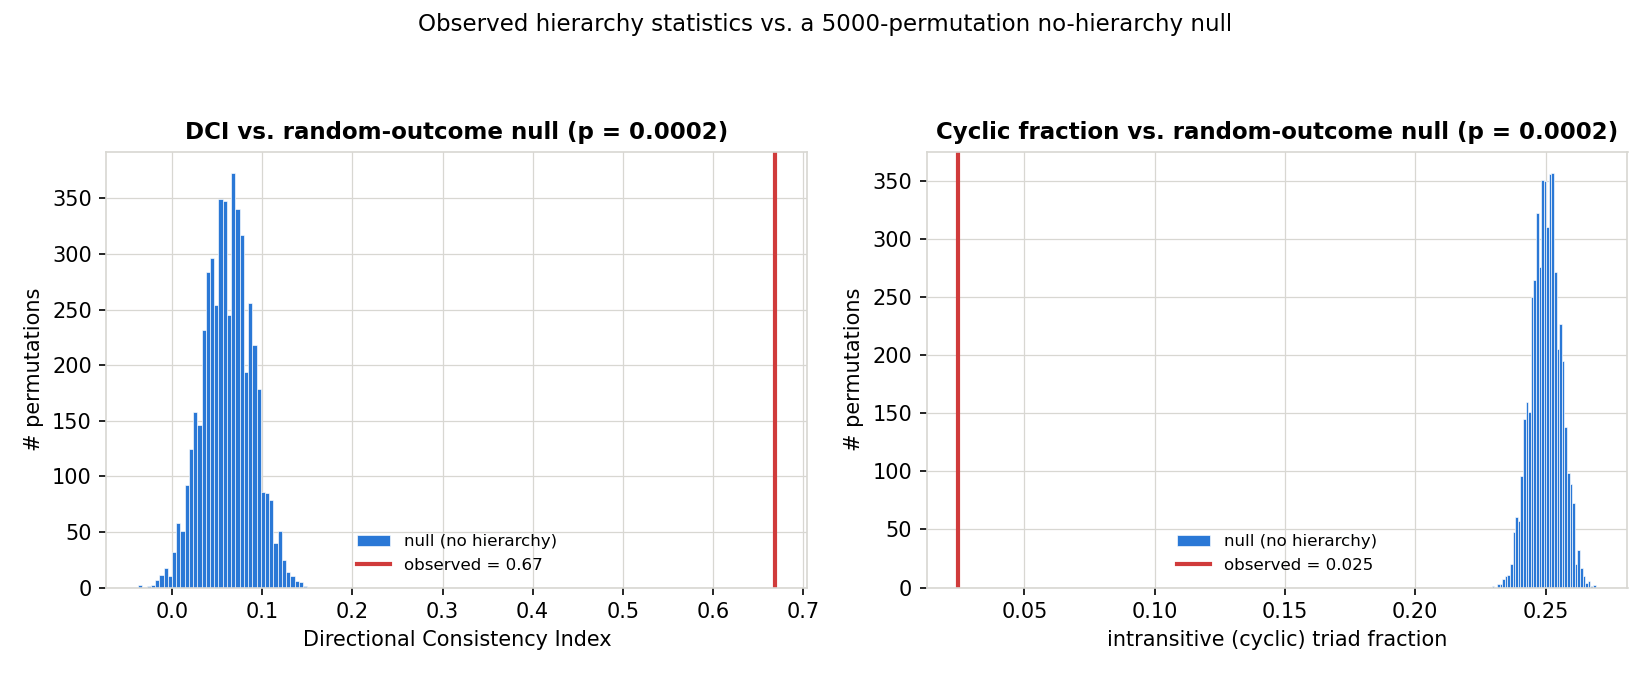

In [25]:
show("08_permutation_test.png", width=900)

**Parametric bootstrap** — observed intransitivity vs. a perfect hierarchy's own sampling noise:

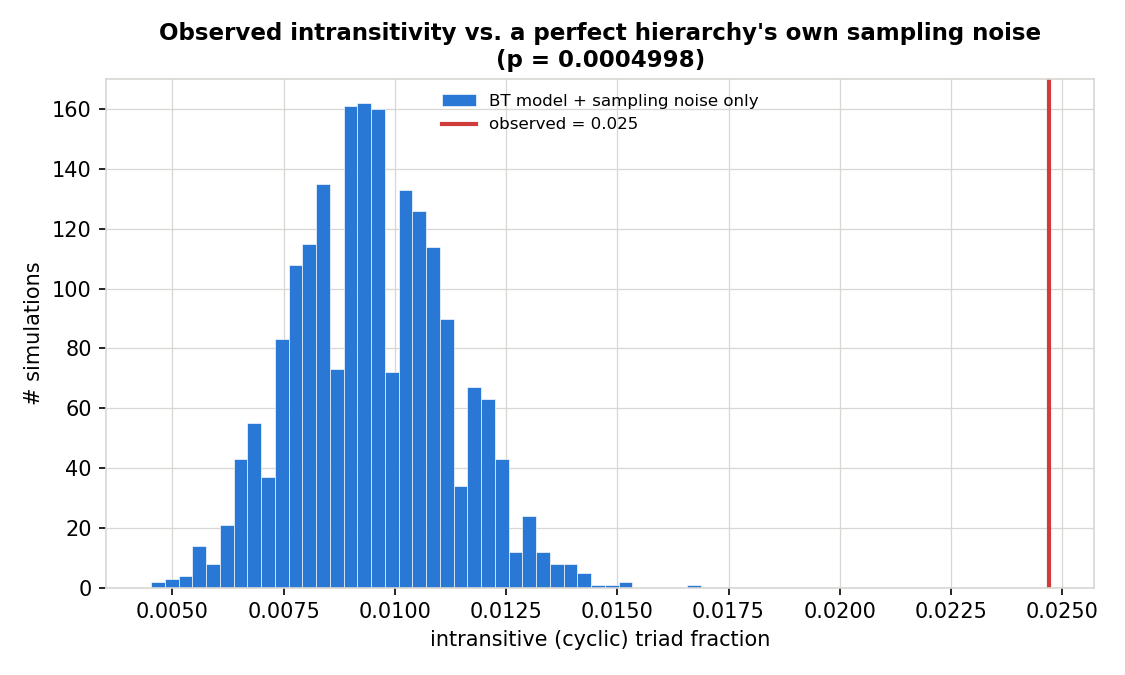

In [26]:
show("09_parametric_bootstrap_intransitivity.png", width=700)

**Bootstrap confidence intervals** on all three headline statistics:

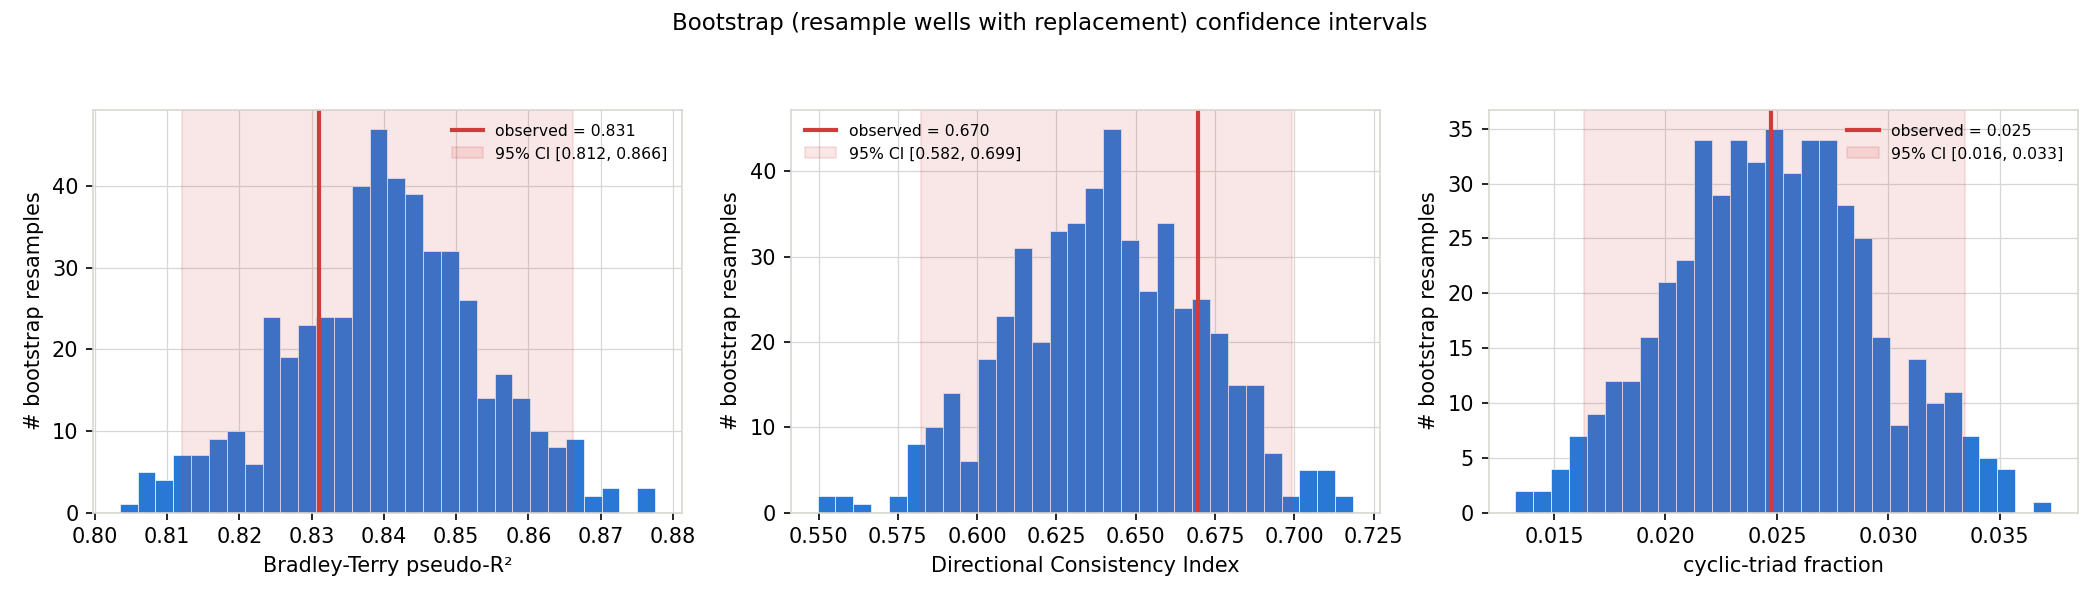

In [27]:
show("10_bootstrap_confidence_intervals.png", width=1050)

**Sensitivity** to excluding hard-to-call pairs:

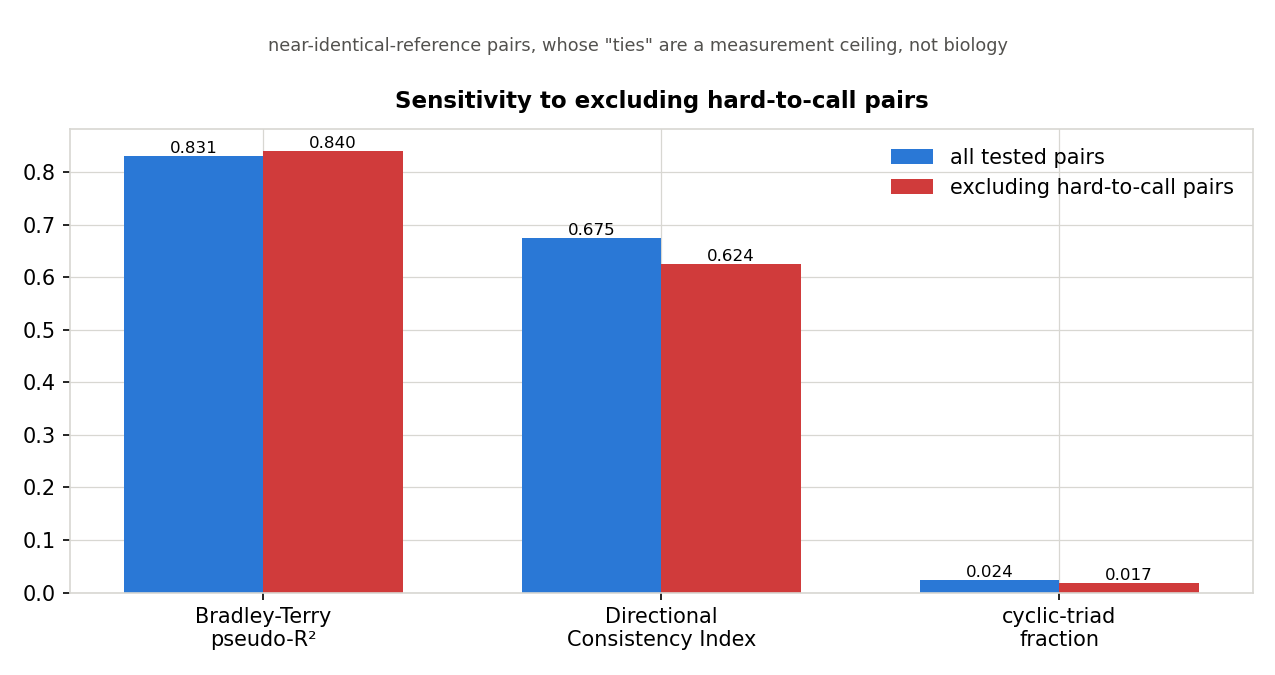

In [28]:
show("11_sensitivity_reliable_pairs.png", width=750)

## Key findings

**1. Interaction scores** — computed for 1,968/2,778 pair wells (810 skipped: one or both
strains lack a reference in `consensus2`, which covers 84/100 strains). Median off-target
read fraction is very low (0%), but a substantial share of wells are hard-to-call because
this strain set has a larger cluster of near-identical references than 20260721's.

**2. Replicate stability** — of 291 replicated pairs, most reproduce tightly (median std
≈ 0.03 once hard-to-call pairs are set aside); 11 show genuine replicate instability.

**3. Competitiveness scores** — 76/100 strains scored (`outputs/r04_strain_competitiveness.csv`).
`J13`, `J5`, `O17` lead; `M13`, `E20`, `O21` trail.

**4. Hierarchy, not a tangle — formally tested, and strikingly similar to 20260721's
independent result.** Bradley-Terry pseudo-R²=0.83 (vs. 0.80 for 20260721), Directional
Consistency Index=0.67 (vs. 0.70), and only 2.5% of evaluable strain triples are cyclic (vs.
3.1%). **A 5,000-permutation randomization test confirms both DCI and cyclic fraction are far
beyond chance** (null DCI = 0.06 ± 0.03, null cyclic fraction = 0.25 ± 0.006 — again matching
the theoretical 1/4 for a random 3-team tournament — both p = 0.0002). As with 20260721, a
formal deviance goodness-of-fit test shows real residual structure beyond a pure hierarchy
(**~5.2x more variation than sampling noise alone would produce** — the more informative,
sample-size-independent number, since the raw p-value would reject any imperfect model at
this read depth). Two independently-built, largely non-overlapping strain libraries show the
same substantially-hierarchical-but-not-pure structure by every measure tried so far.

**5. Additional validation, same story as 20260721:**
- *Excess intransitivity*: observed cyclic fraction (2.5%) is ~2.8x higher than a perfect
  hierarchy's own sampling noise would produce (0.9% ± 0.2%, p = 0.0005) — real, not just noise.
- *Confidence intervals*: pseudo-R² = 0.831 [0.81, 0.87], DCI = 0.670 [0.58, 0.70], cyclic
  fraction = 0.025 [0.016, 0.033] (95% bootstrap CIs).
- *Sensitivity*: excluding hard-to-call pairs actually lowers DCI here too (0.675→0.624) but
  *improves* the cyclic fraction more than 20260721 did (0.024→0.017) — this strain library's
  larger near-identical-reference cluster (step 1) does appear to contribute a modest share
  of its apparent intransitivity, more so than for 20260721.

## Where everything lives

```
pairwise_interaction_experiments/
├── shared_pipelines/                           io_utils.py, mapping_validation.py,
│                                                relative_abundance.py, hierarchy_significance.py,
│                                                experiment_config.py -- all the actual logic,
│                                                shared verbatim across experiments
└── 20260630/analysis/
    ├── config.py                               this experiment's ExperimentConfig
    ├── mapping_validation/                     the read-mapping QC this cohort/reference is built on
    └── relative_abundance/
        ├── outputs/                            r01-r05 as in 20260721, plus:
        │   ├── r07_permutation_test.csv / r07_permutation_null_distributions.csv
        │   ├── r08_bt_goodness_of_fit.csv
        │   ├── r09_parametric_bootstrap_intransitivity.csv / r09_..._null_distributions.csv
        │   ├── r10_bootstrap_confidence_intervals.csv / r10_bootstrap_distributions.csv
        │   ├── r11_sensitivity_reliable_pairs.csv
        │   └── figures/                        the 12 PNGs shown above
        └── <this notebook>
```
